Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


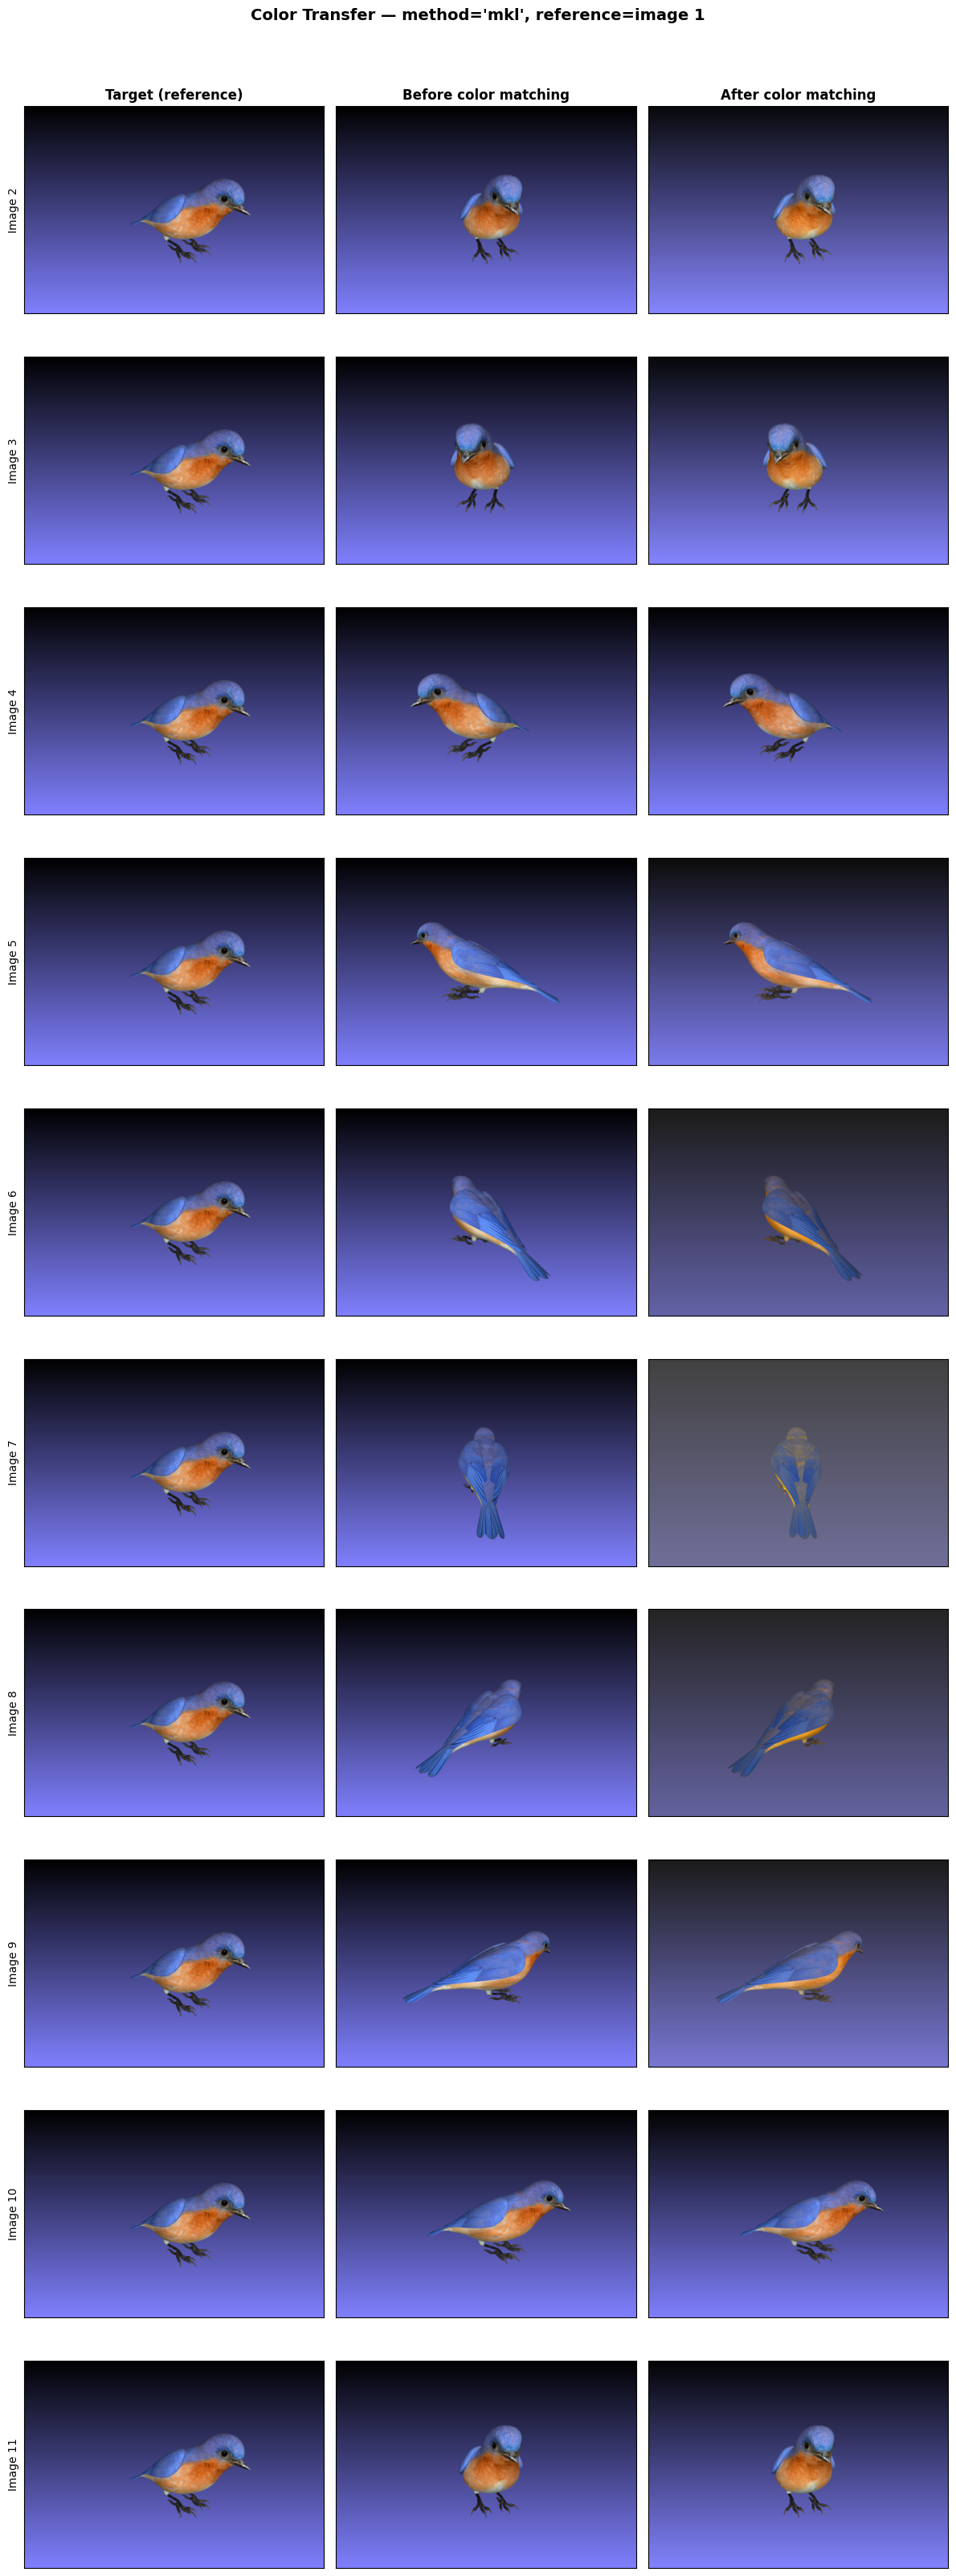

In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from photomesh.color_match import match_colors


IMAGE_DIR = "dataset/images"         
REFERENCE_INDEX = 0                 
METHOD = "mkl"                     

paths = sorted(glob.glob(f"{IMAGE_DIR}/*.png"))
images = [np.array(Image.open(p)).astype(np.float32) for p in paths]
matched = match_colors(images, reference_index=REFERENCE_INDEX, method=METHOD)

others = [i for i in range(len(images)) if i != REFERENCE_INDEX]
n_others = len(others)

fig, axes = plt.subplots(
    n_others, 3,
    figsize=(12, 3.2 * n_others),
    squeeze=False,
)

axes[0, 0].set_title("Target (reference)", fontsize=12, fontweight="bold")
axes[0, 1].set_title("Before color matching", fontsize=12, fontweight="bold")
axes[0, 2].set_title("After color matching", fontsize=12, fontweight="bold")

for row, idx in enumerate(others):
    axes[row, 0].imshow(images[REFERENCE_INDEX].astype(np.uint8))
    axes[row, 0].set_ylabel(f"Image {idx + 1}", fontsize=10)

    axes[row, 1].imshow(images[idx].astype(np.uint8))

    axes[row, 2].imshow(matched[idx].astype(np.uint8))

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    f"Color Transfer — method='{METHOD}', reference=image {REFERENCE_INDEX + 1}",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()